In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
data = yf.download('BTC-USD','2015-01-01','2026-04-28')

[*********************100%***********************]  1 of 1 completed


In [9]:
data = pd.DataFrame(data)

In [11]:
data

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800
...,...,...,...,...,...
2026-04-23,78268.953125,78676.937500,77014.453125,78203.875000,40354900916
2026-04-24,77455.312500,78554.093750,77318.445312,78263.820312,32784213526


In [13]:
len(data)

4135

In [17]:
data.reset_index(inplace= True)

In [23]:
data.drop(columns = ['Date','Open','High','Low','Volume'],inplace = True)

C:\Users\Laraib\AppData\Local\Temp\ipykernel_13100\2051505622.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data.drop(columns = ['Date','Open','High','Low','Volume'],inplace = True)


In [25]:
data

Price,Close
Ticker,BTC-USD
0,314.248993
1,315.032013
2,281.082001
3,264.195007
4,274.473999
...,...
4130,78268.953125
4131,77455.312500
4132,77612.015625


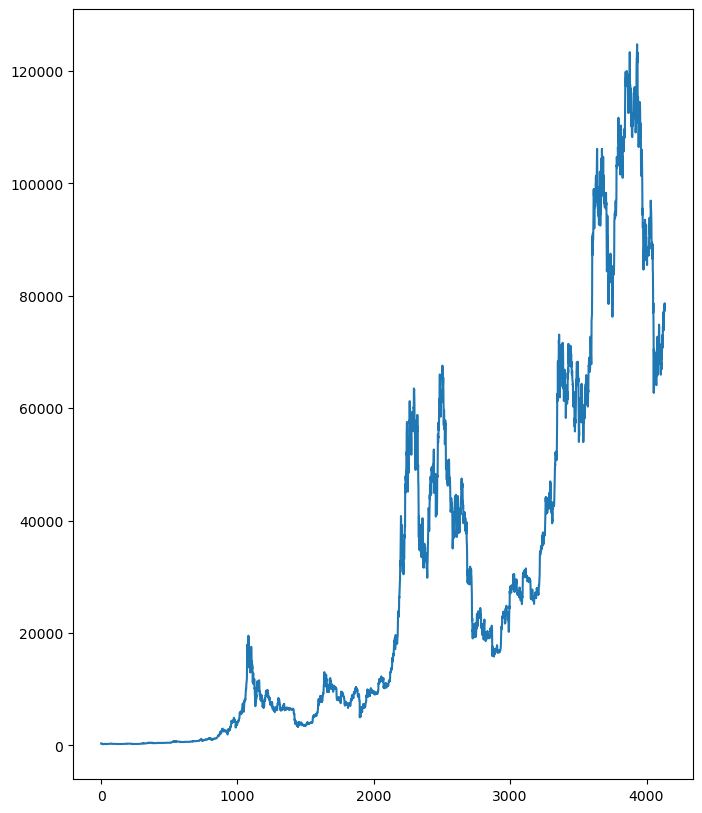

In [27]:
plt.figure(figsize=(8,10))
plt.plot(data)
plt.show()

In [29]:
train_data = data[:-100]
test_data = data[-100:]

In [31]:
train_data.shape

(4035, 1)

In [33]:
test_data.shape

(100, 1)

In [35]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [37]:
train_data_scale = scaler.fit_transform(train_data)

In [39]:
base_days = 100

In [41]:
x = []
y = []
for i in range(base_days, train_data_scale.shape[0]):
    x.append(train_data_scale[i-base_days:i])
    y.append(train_data_scale[i,0])

In [43]:
x[0]

array([[0.00109289],
       [0.00109917],
       [0.00082665],
       [0.00069109],
       [0.0007736 ],
       [0.00086764],
       [0.00093305],
       [0.00084484],
       [0.00090151],
       [0.00077619],
       [0.00070285],
       [0.00072   ],
       [0.00038337],
       [0.        ],
       [0.0002548 ],
       [0.00024077],
       [0.00016983],
       [0.00025877],
       [0.00029507],
       [0.0002666 ],
       [0.00039169],
       [0.00044394],
       [0.00043971],
       [0.00055986],
       [0.00060699],
       [0.00076557],
       [0.00068531],
       [0.00044802],
       [0.00044479],
       [0.0003879 ],
       [0.00031596],
       [0.00039229],
       [0.00048265],
       [0.00039466],
       [0.00039133],
       [0.00031313],
       [0.00035451],
       [0.00039856],
       [0.00036371],
       [0.0003372 ],
       [0.00033503],
       [0.00032978],
       [0.00035048],
       [0.00046016],
       [0.00063591],
       [0.00045533],
       [0.00044744],
       [0.000

In [47]:
x,y = np.array(x), np.array(y)

In [49]:
x = np.reshape(x, (x.shape[0], x.shape[1],1))

In [53]:
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential

In [55]:
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape =(x.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(60,activation= 'relu', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(80,activation='relu', return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(120,activation= 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

C:\Users\Laraib\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [57]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [61]:
model.fit(x,y, epochs=50, verbose =1)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 47s 263ms/step - loss: 0.0384
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 22s 181ms/step - loss: 0.0047
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 30s 245ms/step - loss: 0.0047
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 32s 263ms/step - loss: 0.0036
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 33s 264ms/step - loss: 0.0042
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 32s 257ms/step - loss: 0.0032
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 31s 254ms/step - loss: 0.0033
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 32s 258ms/step - loss: 0.0030
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 34s 276ms/step - loss: 0.0029
Epoch 10/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 33s 269ms/step - loss: 0.0026
Epoch 11/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - loss: 0.0025
Epoch 12/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 34s 279ms/step - loss: 0.0027
Epoch 13/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 33s 267ms/step - loss: 0.0028
Epoch 14/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 33s 265ms/step - loss: 0.0023
Epoch 15/50
123

In [63]:
test_data

Price,Close
Ticker,BTC-USD
4035,93634.429688
4036,92553.593750
4037,88310.906250
4038,89376.960938
4039,89462.453125
...,...
4130,78268.953125
4131,77455.312500
4132,77612.015625


In [65]:
test_data = pd.concat((train_data.tail(100), test_data),ignore_index=True)

In [67]:
test_data

Price,Close
Ticker,BTC-USD
0,113214.367188
1,110807.882812
2,115169.765625
3,115271.078125
4,113118.664062
...,...
195,78268.953125
196,77455.312500
197,77612.015625


In [69]:
test_data_scale= scaler.transform(test_data)

In [71]:
x = []
y = []
for i in range(base_days, test_data_scale.shape[0]):
    x.append(test_data_scale[i-base_days:i])
    y.append(test_data_scale[i,0])

In [75]:
x,y = np.array(x), np.array(y)

In [77]:
x = np.reshape(x, (x.shape[0], x.shape[1],1))

In [79]:
pred = model.predict(x)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step


In [83]:
pred = scaler.inverse_transform(pred)

In [85]:
pred

array([[93047.016],
       [93506.98 ],
       [93386.625],
       [92495.78 ],
       [91163.58 ],
       [89804.586],
       [88742.52 ],
       [88083.27 ],
       [87656.57 ],
       [87452.19 ],
       [87494.51 ],
       [87725.79 ],
       [87708.195],
       [87195.91 ],
       [85910.414],
       [83945.54 ],
       [81832.76 ],
       [79853.44 ],
       [78075.29 ],
       [75898.86 ],
       [73859.62 ],
       [72304.11 ],
       [71424.94 ],
       [71167.4  ],
       [71268.7  ],
       [71348.35 ],
       [71082.71 ],
       [70642.58 ],
       [70293.36 ],
       [70069.625],
       [69938.25 ],
       [69742.22 ],
       [69338.   ],
       [68796.83 ],
       [68342.33 ],
       [68078.484],
       [68005.4  ],
       [67844.336],
       [67410.15 ],
       [67071.53 ],
       [66971.82 ],
       [67020.35 ],
       [67175.766],
       [67290.945],
       [67504.11 ],
       [67826.734],
       [68437.26 ],
       [69243.64 ],
       [69896.76 ],
       [70029.516],


In [111]:
m = y
z = []

future_days = 30

for i in range(base_days, len(m) + future_days):
    m = m.reshape(-1, 1)

    inter = m[-base_days:]   # ✅ FIX: use m instead of inter
    inter = np.array([inter])
    inter = inter.reshape(inter.shape[0], inter.shape[1], 1)

    pred = model.predict(inter)
    m= np.append(m,pred)
    z = np.append(z, pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

In [113]:
z = np.array(z)
z = scaler.inverse_transform(z.reshape(-1,1))

In [115]:
z

array([[77287.61949898],
       [77344.68969796],
       [77253.07740092],
       [77084.8517402 ],
       [76896.45919679],
       [76725.5901597 ],
       [76588.72860522],
       [76487.72341178],
       [76416.03296536],
       [76364.62077985],
       [76325.17804019],
       [76291.42301488],
       [76259.12333161],
       [76225.83609481],
       [76190.3509945 ],
       [76152.34874647],
       [76111.95557935],
       [76069.5576043 ],
       [76025.71913763],
       [75981.05647215],
       [75936.13392416],
       [75891.53066039],
       [75847.632792  ],
       [75804.6927763 ],
       [75762.8813932 ],
       [75722.26546964],
       [75682.85243084],
       [75644.56802465],
       [75607.36769978],
       [75571.16235367]])

In [ ]:
model.save